In [1]:
import numpy as np
from plots import plot_results_for_doc, plot_cost, plot_triangulation_and_level0
from pathlib import Path

# Compliance minimization
(for linear, SVK, and Mooney-Rivlin)

Cost function:

$$
    J_\alpha(\Omega) = \int_\Gamma g\cdot u + \alpha \int_\mathcal{D} \chi_\Omega
$$

State equation:

$$
    u\in H :\quad
    \int_\mathcal{D} A_\Omega W'(I+\nabla u)(\nabla v) = \int_\Gamma g\cdot v
    \qquad \forall v \in H
$$

Adjoint equation:

$$
    p\in H :\quad
    \int_\mathcal{D} A_\Omega W''(I+\nabla u)(\nabla p, \nabla q) = -\int_\Gamma g\cdot q
    \qquad \forall q \in H    
$$

Shape derivative:

$$
    dJ(\Omega)(\theta) = \int_\mathcal{D} S_1\colon\! D\theta
$$

with

$$
    S_1 = A_\Omega \left( W'(I + \nabla u)(\nabla p)\,I  -\nabla u^\top \hat{Q_1} -\nabla p^\top \hat{Q_2}\right) + \alpha\chi_\Omega I
$$

where $\hat{Q_1} = \hat{Q_1}(I + \nabla u)$ and $\hat{Q_2} = \hat{Q_2}(I + \nabla u, \nabla p)$ are defined for each model.

$\hat{Q}_1$ is the first Piola-Kirchhoff stress:

$$
    W'(F)(\delta F) = \delta F \colon\! P(F) = \delta F \colon\! \hat{Q}_1(F) 
$$

$\hat{Q}_2$ is the tangent of the first Piola-Kirchhoff stress:

$$
    W''(F)(\delta F_1, \delta F_2) = \delta F_1 \colon\! P'(F)(\delta F_2) = \delta F_1 \colon\! \hat{Q}_2(F, \delta F_2) 
$$

In [2]:
# Define geometry and boundaries for compliance example
vertices = np.array(
    [
        (0.0, 0.0),
        (2.0, 0.0),
        (2.0, 0.45),
        (2.0, 0.55),
        (2.0, 1.0),
        (0.0, 1.0),
        (0.0, 0.0),
    ]
)
dir_idx, dir_mkr = [6], 1
neu_idx, neu_mkr = [3], 2
dir = np.array(vertices[(dir_idx[0] - 1) : (dir_idx[-1] + 1)])
neu = np.array(vertices[(neu_idx[0] - 1) : (neu_idx[-1] + 1)])
boundaries = [(dir, "red"), (neu, "blue")]

**Numerical tests:**

- We use $\boldsymbol{\sigma}(A) = $ `lmbda*tr(A)*I + 2*mu*A` for lineal and Saint-Venant-Kir. models,

- `lmbda=115.385` and `mu=76.923` (Young's modulus 200 and Poisson's ratio 0.3)

- For Moony-Rivlin we choose $Z(x)=$ `beta*x**2 - gamma*ln(x)` (Ciarlet, Section 4.10), and the values `a_1`, `a_2`, `beta`, `gamma` according to
[Müller, B., 2015. Mixed least squares finite element methods based on inverse stress-strain relations in hyperelasticity. Bericht / Universität Duisburg-Essen, Institut für Mechanik](https://duepublico2.uni-due.de/receive/duepublico_mods_00038480), Sections 2.4.3-5, p. 48.

- `lmbda` and `mu` are the basis for obtaining `a_1`, `a_2`, `beta`, `gamma`.

- We choose $g=(0, -10)$ and multiplier $\alpha=0.25$.

- Stepping Newton method was applied in Saint-Venant-Kir and Moony-Rivlin, with $5$ and $10$ times (by iteration of level set method), respectively.

- We choose `a_2 = 0.56`. For larger values, the stepping Newton method fails to converge.


## *Linear Hooke model*

The energy is given by 

$$
    W(F) = \frac{1}{2}\boldsymbol{\sigma}\left(\mathrm{sym}(F)-I\right)\colon\!\left(\mathrm{sym}(F)-I\right)
$$

and Piola components are

$$
    \hat{Q}_1(F) = \boldsymbol{\sigma}(\mathrm{sym}(F) - I),
    \qquad
    \hat{Q}_2(F,\delta F) = \boldsymbol{\sigma}(\mathrm{sym}(\delta F)) 
$$

In [3]:
!tail -n 5 ../results/t101/out.txt

i = 109 | cost = 0.520933 | nder = 0.1264 | steps = 20 | 
i = 110 | cost = 0.520966 | nder = 0.1301 | steps = 20 | 
> Stopping condition reached!
> Assembly time = 5.489399316000345 s
> Resolution time = 87.40492275799988 s


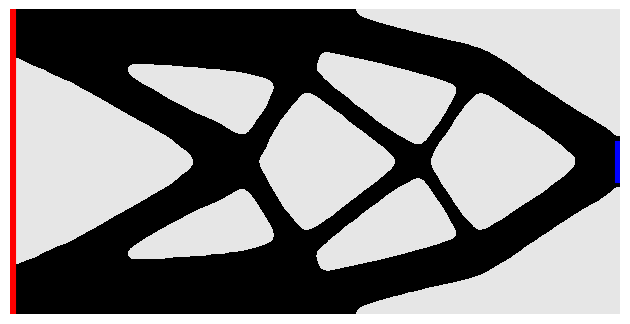

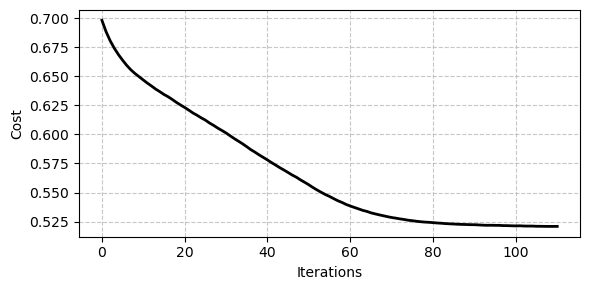

In [4]:
test_path = Path("../results/t101/")
plot_results_for_doc(
    test_path, 110, [[0, 2], [0, 1]], 8, None, boundaries
)
plot_cost(
    np.load("../results/t101/data.npz")["cost"], figsize=(6.0, 3.0)
)

## *Saint-Venant-Kirchhoff model*

The energy is given by

$$
    W(F) = \frac{1}{2}\boldsymbol{\sigma}\left(\frac{FF^\top - I}{2}\right) \colon\!\left(\frac{FF^\top - I}{2}\right)
$$

and the Piola components are

$$
    \hat{Q}_1 (F) = F\,\boldsymbol{\sigma}\left(\frac{FF^\top - I}{2}\right),
$$
$$
    \hat{Q}_2(F,\delta F) =
    \delta F\, \boldsymbol{\sigma}\left(\frac{FF^\top - I}{2}\right) +
    F\, \boldsymbol{\sigma}(\mathrm{sym}(F^\top \delta F))
$$

In [5]:
!tail -n 5 ../results/t102/out.txt

i = 113 | cost = 0.518815 | nder = 0.2284 | steps = 19 | 
i = 114 | cost = 0.518909 | nder = 0.2443 | steps = 19 | 
> Stopping condition reached!
> Assembly time = 5.5167422920000035 s
> Resolution time = 927.3400252179999 s


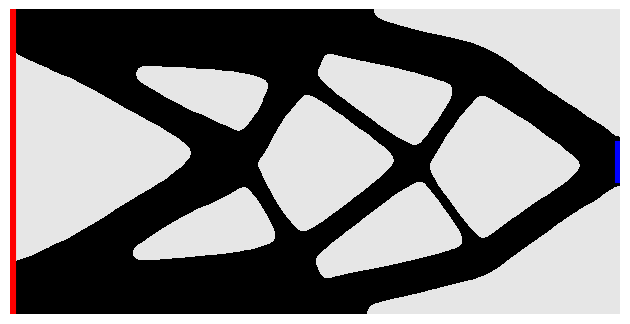

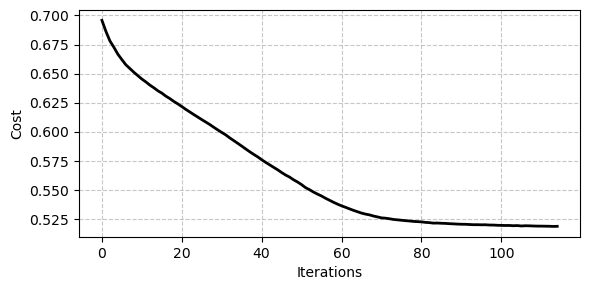

In [6]:
test_path = Path("../results/t102/")
plot_results_for_doc(
    test_path, 114, [[0, 2], [0, 1]], 8, None, boundaries
)
plot_cost(
    np.load("../results/t102/data.npz")["cost"], figsize=(6.0, 3.0)
)

## *Mooney-Rivlin model*

Set $H=\mathrm{Cof}(F)$ and $J=\det(F)$. The energy is given by

$$
    W(F) = \frac{a_1}{2}F\colon\!F + \frac{a_2}{2}H\colon\!H +Z(J)
$$

$Z(x)=$ `beta*x**2 - gamma*ln(x)`, with Piola components
$$
    \hat{Q}_1(F) = a_1 F + a_2 M(F; H) + Z'(J) H,
$$

$$
    \hat{Q}_2(F,\delta F) =
    a_1\delta F +
    a_2 M(F; \mathrm{Cof}'(F)(\delta F)) +
    a_2 M'(F;H)(\delta F) +
    Z'(J)M(F;\delta F) +
    Z''(J)(H\colon\!\delta F)H
$$

- $M(A;B)$ has different expressions for 2D and 3D

- $M'(A;B)(\delta A) = 0$ in 2D and $M'(A;B)(\delta A) = M(\delta A; B)$ in 3D

- $\mathrm{Cof}(F)$ is different in 2D and 3D; in both cases the Cayley-Hamilton theorem provides expressions without $F^{-1}$ 💡

- $\mathrm{Cof}'(F)(\delta F)\colon\!B = \delta F\colon\!M(F;B)$

- $\mathrm{Cof}''(F)(\delta F_1, \delta F_2)\colon\!B = \delta F_1\colon\!M'(F;B)(\delta F_2)$

In [7]:
!tail -n 5 ../results/t103/out.txt

i = 108 | cost = 0.519959 | nder = 0.2329 | steps = 18 | 
i = 109 | cost = 0.520036 | nder = 0.2507 | steps = 19 | 
> Stopping condition reached!
> Assembly time = 5.388503342000149 s
> Resolution time = 1769.4981226849998 s


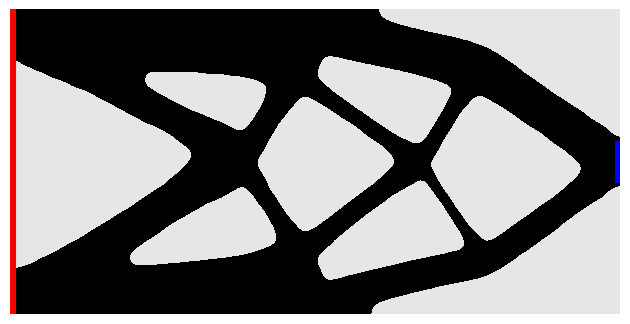

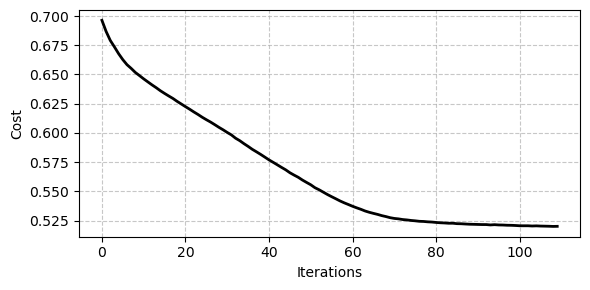

In [8]:
test_path = Path("../results/t103/")
plot_results_for_doc(
    test_path, 109, [[0, 2], [0, 1]], 8, None, boundaries
)
plot_cost(
    np.load("../results/t103/data.npz")["cost"], figsize=(6.0, 3.0)
)

# Gripping mechanism

## *Linear Hooke model*

In [9]:
# Define geometry and boundaries for gripping example
vertices = np.array(
    [
        (0.0, 0.0),
        (0.9, 0.0),
        (1.0, 0.0),
        (1.0, 0.48),
        (1.0, 0.52),
        (1.0, 1.0),
        (0.9, 1.0),
        (0.0, 1.0),
        (0.0, 0.6),
        (0.1, 0.6),
        (0.1, 0.52),
        (0.1, 0.48),
        (0.1, 0.4),
        (0.0, 0.4),
    ]
)

dirR_idx, dirR_mkr = [4], 1
dirL_idx, dirL_mkr = [11], 2
neuRT_idx, neuRT_mkr = [6], 3
neuRB_idx, neuRB_mkr = [2], 4
neuLT_idx, neuLT_mkr = [9], 5
neuLB_idx, neuLB_mkr = [13], 6    

boundary_parts = [
(dirR_idx, dirR_mkr, "dir_right"),
(dirL_idx, dirL_mkr, "dir_left"),
(neuRT_idx, neuRT_mkr, "neu_right_top"),
(neuRB_idx, neuRB_mkr, "neu_right_bottom"),
(neuLT_idx, neuLT_mkr, "neu_left_top"),
(neuLB_idx, neuLB_mkr, "neu_left_bottom"),
]


dir_idx, dir_mkr = [6], 1
neu_idx, neu_mkr = [3], 2

dirR = np.array(vertices[(dirR_idx[0] - 1) : (dirR_idx[-1] + 1)])
dirL = np.array(vertices[(dirL_idx[0] - 1) : (dirL_idx[-1] + 1)])
neuRT = np.array(vertices[(neuRT_idx[0] - 1) : (neuRT_idx[-1] + 1)])
neuRB = np.array(vertices[(neuRB_idx[0] - 1) : (neuRB_idx[-1] + 1)])
neuLT = np.array(vertices[(neuLT_idx[0] - 1) : (neuLT_idx[-1] + 1)])
neuLB = np.array(vertices[(neuLB_idx[0] - 1) : (neuLB_idx[-1] + 1)])

boundaries = [(dirR, "red"), (dirL, "red"), (neuRT, "blue"), (neuRB, "blue"), (neuLT, "blue"), (neuLB, "blue")]

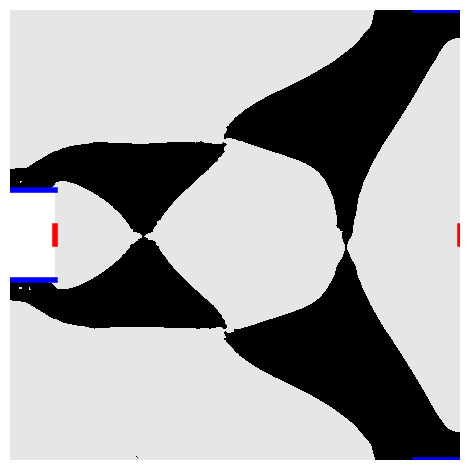

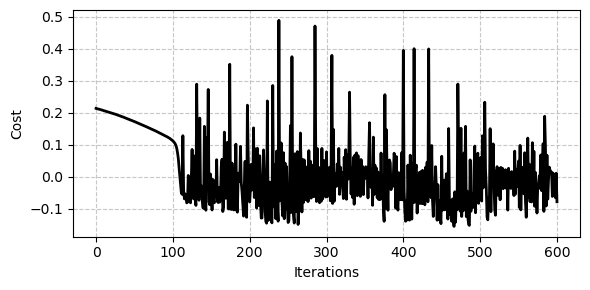

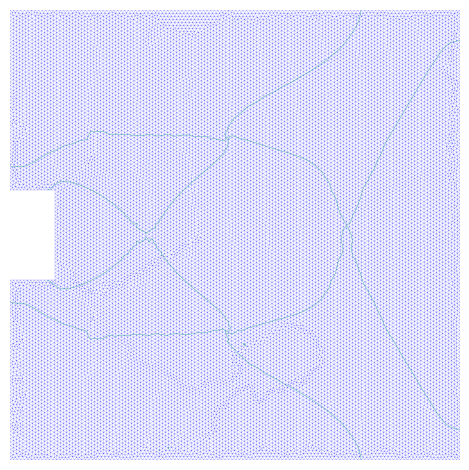

In [10]:
test_path = Path("../results/t106/")
plot_results_for_doc(
    test_path, 600, [[0, 1], [0, 1]], 4, None, boundaries
)
plot_cost(
    np.load("../results/t106/data.npz")["cost"], figsize=(6.0, 3.0)
)
plot_triangulation_and_level0(test_path, 400, [[0, 1], [0, 1]], lw=0.25, filename="p.pdf")

**Questions:**

For gripping mechanism, I would like to consider the cost functional:

$$
    J(\Omega) = \int_\mathcal{D} k(x) |\boldsymbol{\sigma} - \boldsymbol{\sigma}_0|^2
$$

$k(x)=1$ in regions where the force is applied and $0.1$ elsewhere, $\boldsymbol{\sigma}$ is the stress tensor (it depends on $\nabla u$ 🚨) and $\boldsymbol{\sigma}_0$ is a fixed stress. See [Minimum stress optimal design with the level set method](https://www.sciencedirect.com/science/article/pii/S0955799708000386), gripping mechanism example (not many weak hinges).